In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from statsmodels.tsa.seasonal import seasonal_decompose

In [4]:
data = pd.read_csv("D:/Downloads/Yearly_revenue.xls")

In [5]:
data.head(5)

,Yearly_revenue
0,3307
1,3556
2,3601
3,3721
4,4036


In [6]:
#convert indices as years
data.index = data.index + 1982

In [7]:
data.index

RangeIndex(start=1982, stop=2025, step=1)

In [8]:
data.head(5)

,Yearly_revenue
1982,3307
1983,3556
1984,3601
1985,3721
1986,4036


Text(0, 0.5, 'Yearly_revenue')

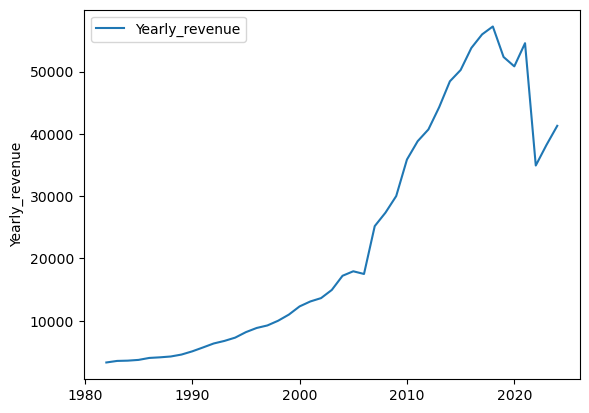

In [9]:
sns.lineplot(data)
plt.ylabel("Yearly_revenue")

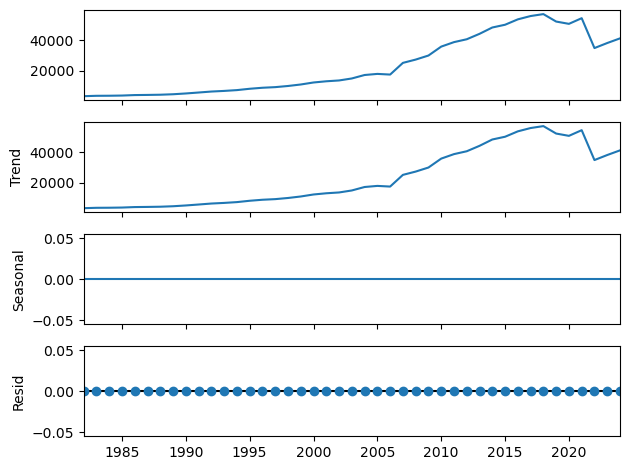

In [10]:
#decomposition of the time series - additive model
result = seasonal_decompose(data[['Yearly_revenue']], model = 'additve', period = 1)
result.plot()
plt.show()

In [11]:
#Although there is long term trend present there is no seasonal component present , this shows some type of cyclic component present, therefore there was no need of decomposition.

In [12]:
import pymannkendall as mk

In [13]:
#Perform the Mann-Kendall test
#H0: There is no monotonic trend in the series

mk.original_test(data['Yearly_revenue'])

Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(0.0), z=np.float64(8.56071397786077), Tau=np.float64(0.9069767441860465), s=np.float64(819.0), var_s=9130.333333333334, slope=np.float64(1225.8695652173913), intercept=np.float64(-10793.260869565216))

In [14]:
#Train test splitting
train_df = data[:int(data.shape[0]*0.7)]
test_df = data[int(data.shape[0]*0.7):]

train_df.head(5)

,Yearly_revenue
1982,3307
1983,3556
1984,3601
1985,3721
1986,4036


In [15]:
#ADF Test
#H0: Series is not stationary, ie,e series has a unit root
#H1: Series is stationary, ie,e series has no unit root

from statsmodels.tsa.stattools import adfuller 
result = adfuller(data)

print("ADF Statistic:", result[0])
print("p-value:",result[1])

ADF Statistic: -1.2182029152074476
p-value: 0.6657166727999055


In [16]:
#KPSS Test
#H0: Series is trend stationary, ie,e series has no unit root
#H1: Series is non-stationary, ie,e series has a unit root

In [17]:
from statsmodels.tsa.stattools import kpss
kp = kpss(data)
p = kp[1]

print("p-value for KPSS Test(untransformed) = ",p)

p-value for KPSS Test(untransformed) =  0.01


C:\Users\Dell\AppData\Local\Temp\ipykernel_11900\1970154832.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp = kpss(data)


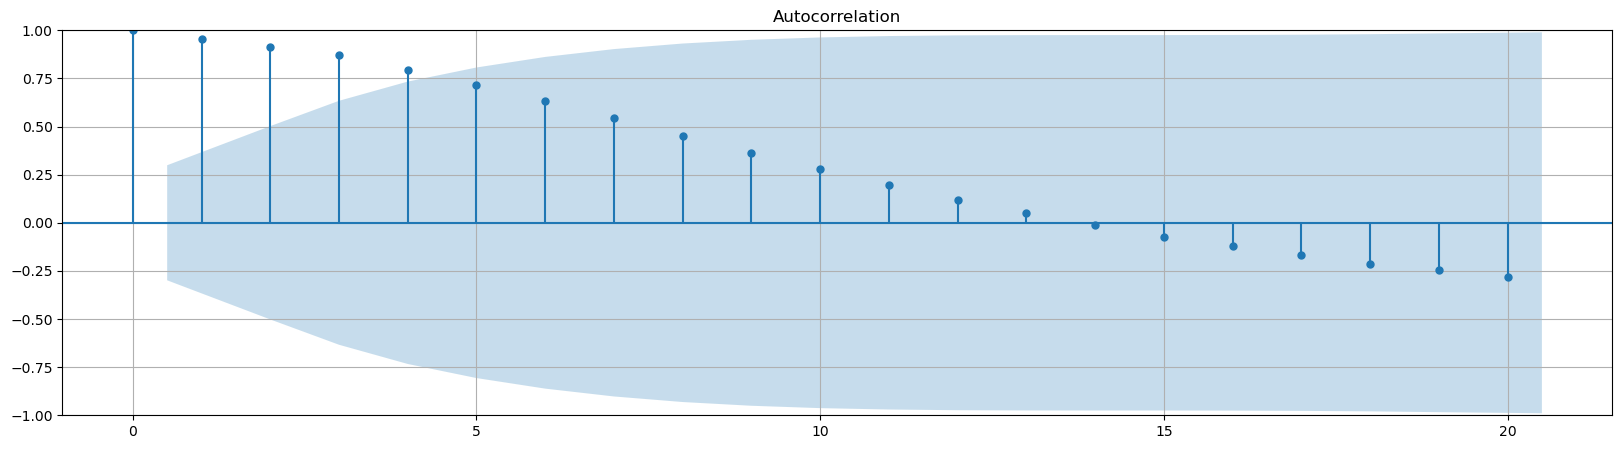

In [20]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize = (20,5))
plt.grid()
plot_acf(data, ax = plt.gca(), lags = 20)
plt.show()

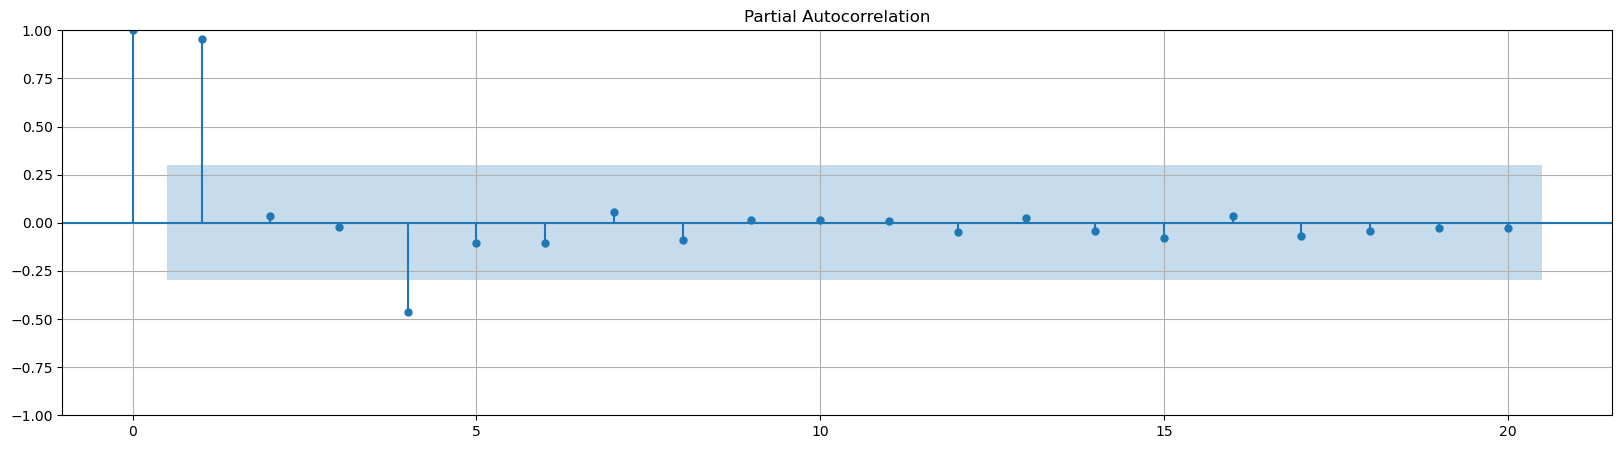

In [21]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize = (20,5))
plt.grid()
plot_pacf(data, ax = plt.gca(), lags = 20)
plt.show()

In [ ]:
#No, need for seasonal differencing

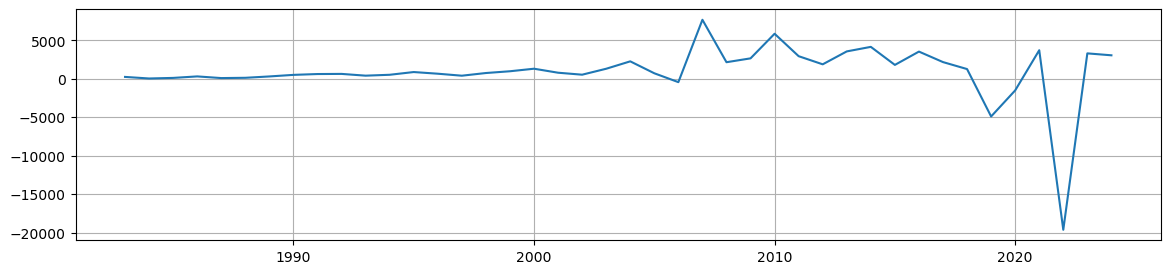

In [23]:
#NON Seasonal differencing
diff = data.diff().dropna()
plt.figure(figsize = (14,3))  #making trend data stationary
plt.grid()
plt.plot(diff)
plt.show()

In [24]:
from statsmodels.tsa.stattools import adfuller 
result = adfuller(diff)

print("ADF Statistic:", result[0])
print("p-value:",result[1])

ADF Statistic: -2.088805040010332
p-value: 0.24903991313852647


In [25]:
#KPSS Test 
from statsmodels.tsa.stattools import kpss
kp = kpss(diff)
p = kp[1]

print("p-value for KPSS Test(untransformed) = ",p)

p-value for KPSS Test(untransformed) =  0.1


C:\Users\Dell\AppData\Local\Temp\ipykernel_11900\1400596546.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(diff)


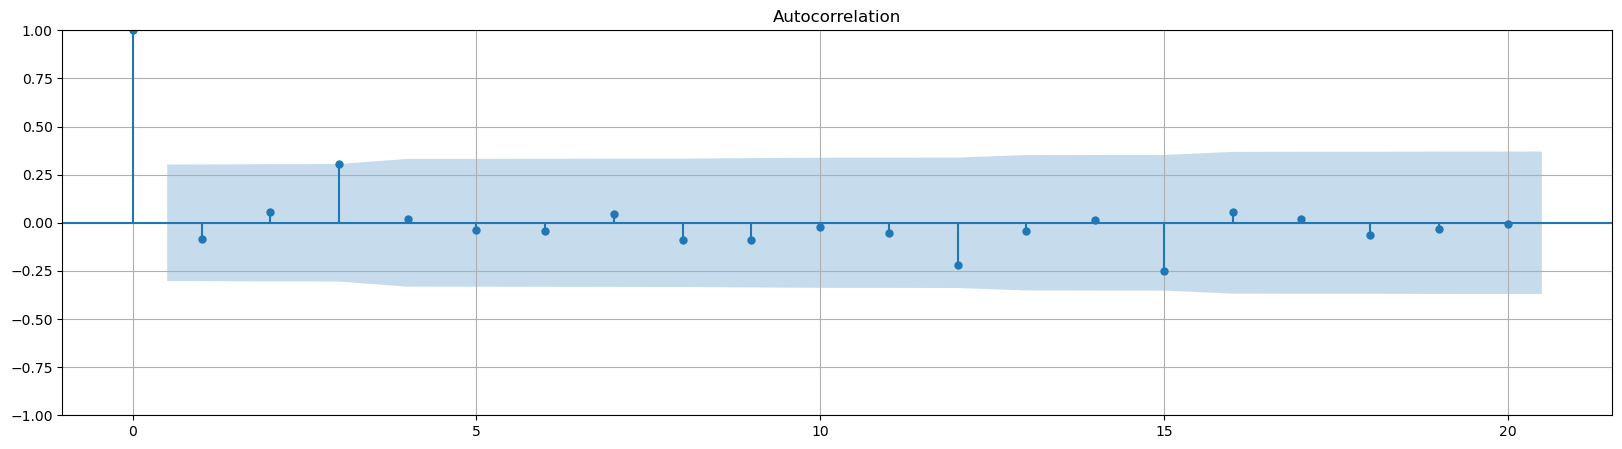

In [38]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize = (20,5))
plt.grid()
plot_acf(diff, ax = plt.gca(), lags = 20)
plt.show()

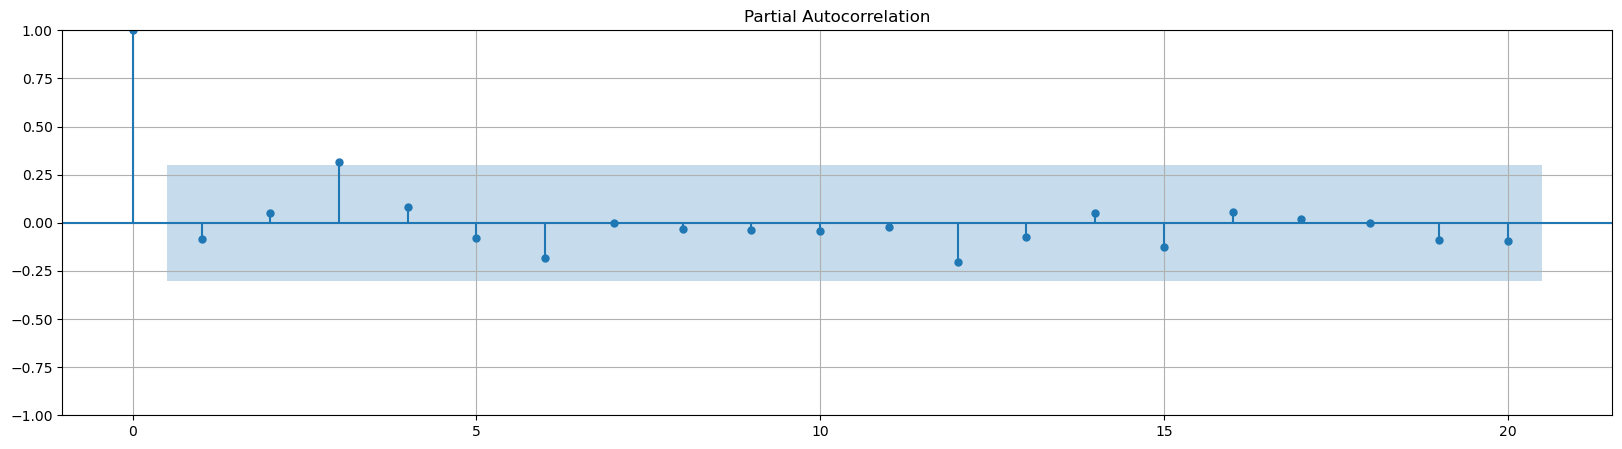

In [39]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize = (20,5))
plt.grid()
plot_pacf(diff, ax = plt.gca(), lags = 20)
plt.show()

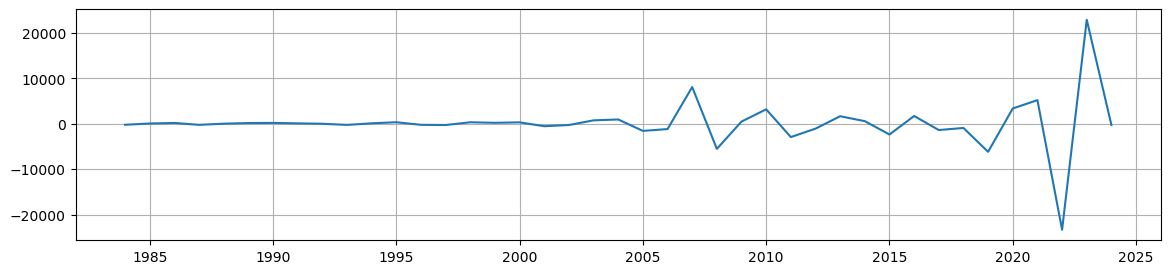

In [29]:
#NON Seasonal differencing
diff2 = diff.diff().dropna()
plt.figure(figsize = (14,3))  #making trend data stationary
plt.grid()
plt.plot(diff2)
plt.show()

In [30]:
from statsmodels.tsa.stattools import adfuller 
result = adfuller(diff2)

print("ADF Statistic:", result[0])
print("p-value:",result[1])

ADF Statistic: -1.0813888236776397
p-value: 0.7224364779199984


In [31]:
#KPSS Test 
from statsmodels.tsa.stattools import kpss
kp = kpss(diff2)
p = kp[1]

print("p-value for KPSS Test(untransformed) = ",p)

p-value for KPSS Test(untransformed) =  0.1


C:\Users\Dell\AppData\Local\Temp\ipykernel_11900\3810939247.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(diff2)


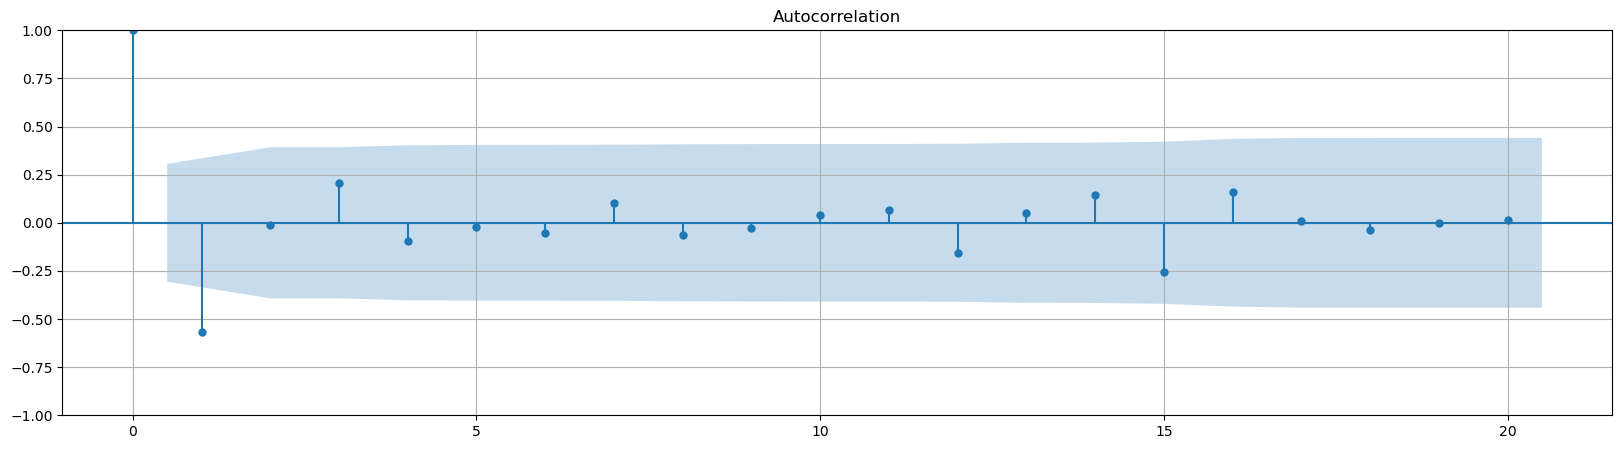

In [34]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize = (20,5))
plt.grid()
plot_acf(diff2, ax = plt.gca(), lags = 20)
plt.show()

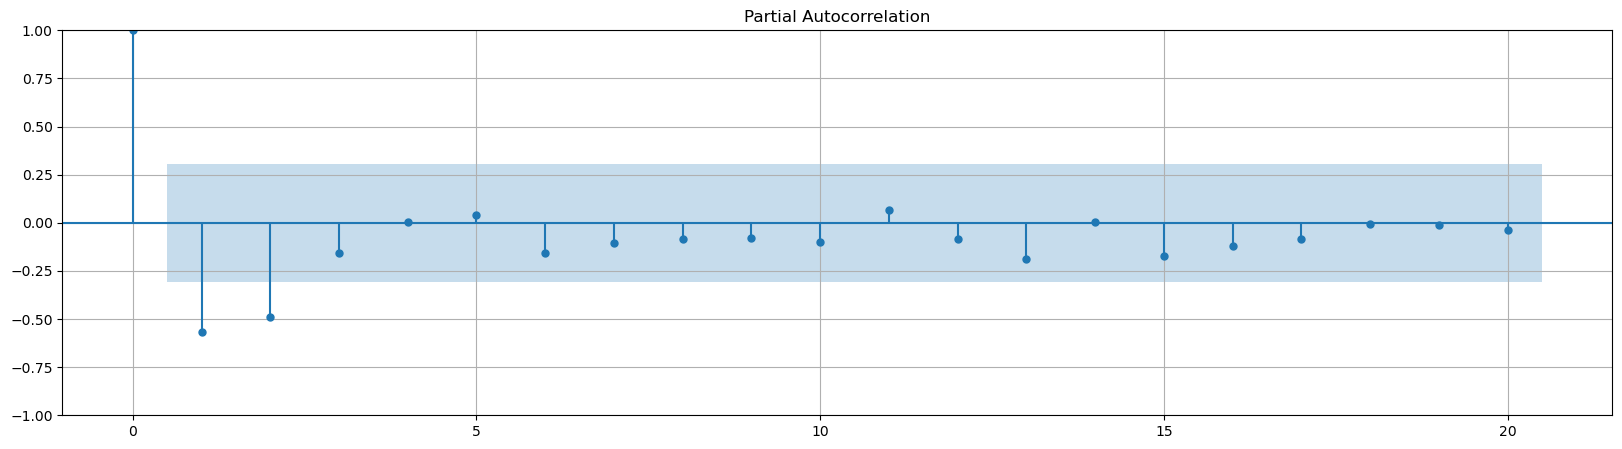

In [35]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize = (20,5))
plt.grid()
plot_pacf(diff2, ax = plt.gca(), lags = 20)
plt.show()

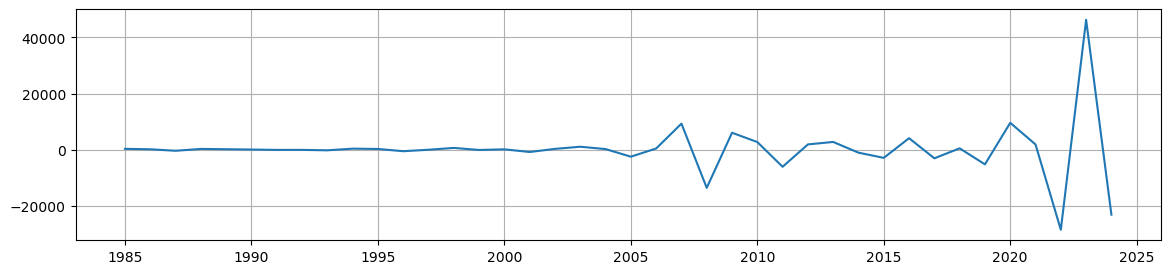

In [32]:
#NON Seasonal differencing
diff3 = diff2.diff().dropna()
plt.figure(figsize = (14,3))  #making trend data stationary
plt.grid()
plt.plot(diff3)
plt.show()

In [33]:
from statsmodels.tsa.stattools import adfuller 
result = adfuller(diff3)

print("ADF Statistic:", result[0])
print("p-value:",result[1])

ADF Statistic: -9.3931470997056
p-value: 6.479569918726343e-16


In [ ]:
#P-value < 0.05, reject H0. the series has now become stationary

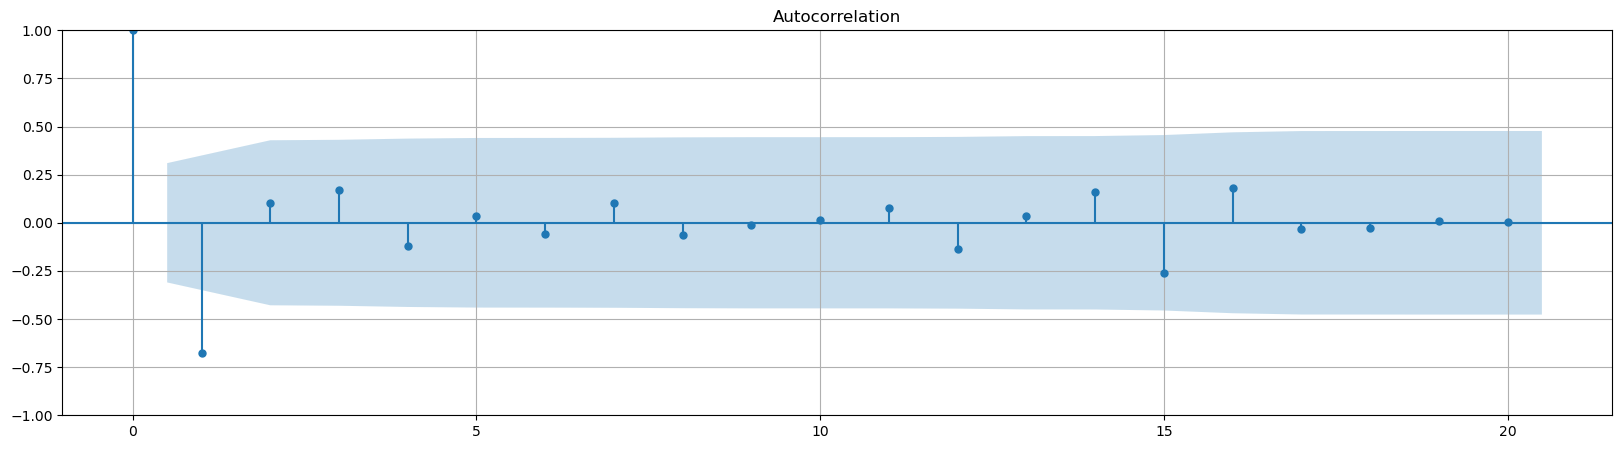

In [40]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize = (20,5))
plt.grid()
plot_acf(diff3, ax = plt.gca(), lags = 20)
plt.show()

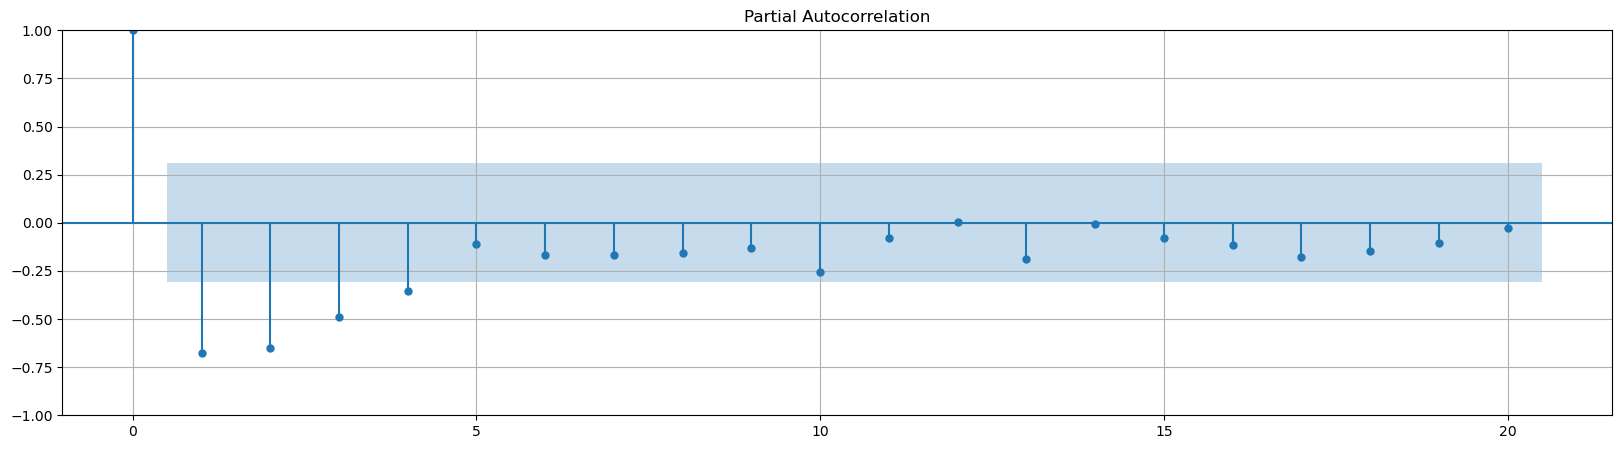

In [41]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize = (20,5))
plt.grid()
plot_pacf(diff3, ax = plt.gca(), lags = 20)
plt.show()

In [ ]:
#Series Has Now become stationary.